# AI-Driven Flood Scenarios & Insurability — a methods demonstrator

**Author:** Sahar Mirzabaki · **Context:** demonstrator for the UvA / FIRM *Pillar 3* PhD
("AI-Driven Flood Scenarios and Insurability Maps").

This notebook is a **small, self-contained proof of concept**, not a solved research problem.
It runs end-to-end on a laptop CPU in a few minutes (seconds on a GPU) using **synthetic,
physics-motivated data**, so it needs no external downloads. Its only purpose is to show, concretely,
how I would approach the four building blocks the Pillar 3 project asks for:

| Pillar 3 task (from the vacancy) | What this notebook shows |
|---|---|
| Extend hydraulic flood-scenario sets with a fast surrogate | A **U-Net emulator** that reproduces a hydraulic model's depth map from *(terrain, forcing)* |
| Represent flood impacts **probabilistically** | **MC-dropout uncertainty** with an empirical calibration/coverage check |
| Work with **spatial** data and non-linear connectivity | Everything runs on a raster grid; the "truth" includes flood-fill **connectivity**, a non-linearity a naive `relu(h−z)` cannot capture |
| Rapid damage estimation & **insurability** maps | Emulator → depth-damage curve → **Expected Annual Damage** → insurability classification |

> **Honesty note.** The "hydraulic model" here is a cheap flood-fill *proxy* standing in for the
> decades of real hydraulic modelling the project builds on. The point is the **ML methodology and
> the plumbing between the pieces**, not the hydrology. Where real inputs would go (Copernicus DEM,
> Copernicus EMS flood extents, JRC depth-damage functions, KNMI'23 climate scenarios) is flagged in
> the final section.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, time
from collections import deque

torch.set_num_threads(4)
RNG = np.random.default_rng(0); torch.manual_seed(0)
N = 56  # raster grid size (NxN)

## 1 · A synthetic hydraulic model (proxy)

We generate a river **floodplain**: terrain slopes down toward a wandering river channel, with
smooth roughness on top. A "flood" for a given boundary **water level** (the *forcing*) is produced
by a **flood fill** from the channel through connected cells that lie below the water level. Because
flooding depends on *connectivity*, depth is a genuinely **non-linear** function of terrain + forcing (isolated basins below the water level stay dry unless the flood actually reaches them) —
which is what gives the emulator something non-trivial to learn.

In [2]:
def gaussian_random_field(n, scale, rng):
    """Smooth low-frequency random field via spectral filtering."""
    white = rng.normal(size=(n, n))
    f = np.fft.fftfreq(n); kx, ky = np.meshgrid(f, f)
    k = np.sqrt(kx**2 + ky**2) + 1e-6
    fld = np.fft.ifft2(np.fft.fft2(white) * np.exp(-(k * scale) ** 2)).real
    return (fld - fld.mean()) / (fld.std() + 1e-8)

def make_terrain(rng):
    # DEM (m): floodplain sloping to a river, plus a LEVEE with a breach protecting a low polder.
    # The levee is the key non-linearity: land behind an intact levee stays dry even when it sits
    # below the water level, so a naive relu(h-z) "bathtub" model cannot get it right.
    col = np.zeros(N, int); c = rng.integers(N // 3, 2 * N // 3)
    for r in range(N):
        c = int(np.clip(c + rng.integers(-1, 2), 4, N - 5)); col[r] = c
    yy, xx = np.mgrid[0:N, 0:N]
    dist = np.abs(xx - col[:, None])
    z = 0.13 * dist + 1.3 * gaussian_random_field(N, 7.0, rng) + np.linspace(0, 1.5, N)[:, None]
    z = z - z.min()
    channel = (dist <= 1.5).astype(np.float32)
    z = np.where(channel > 0, z - 1.0, z)
    s = rng.choice([-1, 1]); off = rng.integers(7, 11)          # levee side & offset from river
    levee_center = np.clip(col + s * off, 2, N - 3)
    lev = np.abs(xx - levee_center[:, None]) <= 1.0             # ridge cells
    polder = (s * (xx - col[:, None])) > off                    # protected land beyond the levee
    z = np.where(polder, z - 2.0, z)                            # lower the polder
    z = z + 5.0 * lev                                           # raise the levee
    brow = rng.integers(0, N); bw = rng.integers(2, 4)          # a breach gap in the levee
    z = np.where((np.abs(yy - brow) < bw) & lev, z - 5.0, z)
    z = z - z.min()
    return z.astype(np.float32), channel

def hydraulic_proxy(z, channel, water_level):
    """Flood fill from the channel through connected below-water cells -> depth map."""
    below = z < water_level
    flooded = np.zeros_like(below); q = deque()
    for idx in zip(*np.where(below & (channel > 0))):
        flooded[idx] = True; q.append(idx)
    while q:
        r, c = q.popleft()
        for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < N and 0 <= nc < N and not flooded[nr, nc] and below[nr, nc]:
                flooded[nr, nc] = True; q.append((nr, nc))
    return np.where(flooded, np.clip(water_level - z, 0, None), 0.0).astype(np.float32)

def make_dataset(n, rng):
    """Each sample: random floodplain + random water level -> depth map."""
    X, Y, WL = [], [], []
    for _ in range(n):
        z, ch = make_terrain(rng); wl = rng.uniform(2.0, 6.5)
        X.append(z); Y.append(hydraulic_proxy(z, ch, wl)); WL.append(wl)
    X = np.stack(X)[:, None]; WL = np.array(WL, np.float32)
    X = np.concatenate([X, np.ones_like(X) * WL[:, None, None, None]], 1)  # [DEM, forcing]
    return X.astype(np.float32), np.stack(Y)[:, None].astype(np.float32), WL

Xtr, Ytr, WLtr = make_dataset(400, RNG)
Xte, Yte, WLte = make_dataset(120, RNG)
xm, xs = Xtr.mean((0, 2, 3), keepdims=True), Xtr.std((0, 2, 3), keepdims=True) + 1e-6
Xtr_n, Xte_n = (Xtr - xm) / xs, (Xte - xm) / xs
print("train:", Xtr.shape, " flooded fraction:", round(float((Ytr > 0).mean()), 3))

train: (400, 2, 56, 56)  flooded fraction: 0.189


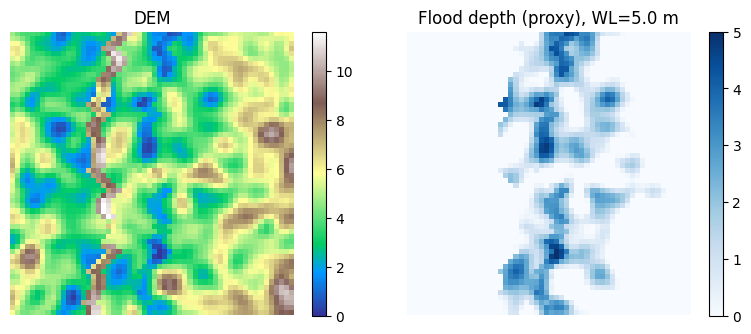

In [3]:
# quick look at one scenario
z, ch = make_terrain(np.random.default_rng(3)); d = hydraulic_proxy(z, ch, 5.0)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
im = ax[0].imshow(z, cmap="terrain"); ax[0].set_title("DEM"); fig.colorbar(im, ax=ax[0], fraction=.046)
im = ax[1].imshow(d, cmap="Blues"); ax[1].set_title("Flood depth (proxy), WL=5.0 m"); fig.colorbar(im, ax=ax[1], fraction=.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 2 · The emulator — a U-Net with dropout

A compact U-Net maps the 2-channel input **[DEM, forcing]** to a non-negative depth map
(`Softplus` output). Dropout layers stay in the architecture so we can reuse them for
**MC-dropout** uncertainty in the next section. On real data this surrogate replaces an expensive
hydraulic solver, turning minutes/hours per scenario into milliseconds — which is what makes rapid,
probabilistic scenario sets feasible.

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, cin, cout, p=0.12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(), nn.Dropout2d(p),
            nn.Conv2d(cout, cout, 3, padding=1), nn.ReLU())
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, cin=2, base=16, p=0.12):
        super().__init__()
        self.d1 = DoubleConv(cin, base, p);      self.d2 = DoubleConv(base, base*2, p)
        self.pool = nn.MaxPool2d(2);             self.bott = DoubleConv(base*2, base*4, p)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2); self.c2 = DoubleConv(base*4, base*2, p)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2);   self.c1 = DoubleConv(base*2, base, p)
        self.head = nn.Conv2d(base, 1, 1);       self.sp = nn.Softplus()
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); b = self.bott(self.pool(c2))
        u2 = self.c2(torch.cat([self.up2(b), c2], 1))
        u1 = self.c1(torch.cat([self.up1(u2), c1], 1))
        return self.sp(self.head(u1))

model = UNet(); print(sum(p.numel() for p in model.parameters()), "parameters")

116897 parameters


In [5]:
opt = torch.optim.Adam(model.parameters(), 1e-3); lossf = nn.MSELoss()
Xt, Yt = torch.tensor(Xtr_n), torch.tensor(Ytr)
Xv, Yv = torch.tensor(Xte_n), torch.tensor(Yte)

EPOCHS, BS = 30, 16          # ~seconds on GPU; a couple of minutes on CPU
t0 = time.time()
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(len(Xt)); tot = 0.0
    for i in range(0, len(Xt), BS):
        idx = perm[i:i+BS]
        opt.zero_grad(); loss = lossf(model(Xt[idx]), Yt[idx])
        loss.backward(); opt.step(); tot += loss.item() * len(idx)
    if (ep + 1) % 6 == 0:
        model.eval()
        with torch.no_grad(): vr = torch.sqrt(lossf(model(Xv), Yv)).item()
        print(f"epoch {ep+1:3d}  train_mse {tot/len(Xt):.4f}  test_rmse {vr:.4f} m")
print(f"trained in {time.time()-t0:.0f}s")

epoch   6  train_mse 0.2163  test_rmse 0.4440 m


epoch  12  train_mse 0.1716  test_rmse 0.4102 m


epoch  18  train_mse 0.1630  test_rmse 0.3839 m


epoch  24  train_mse 0.1352  test_rmse 0.3795 m


epoch  30  train_mse 0.1223  test_rmse 0.3692 m
trained in 204s


TEST  RMSE = 0.369 m   R2 = 0.801


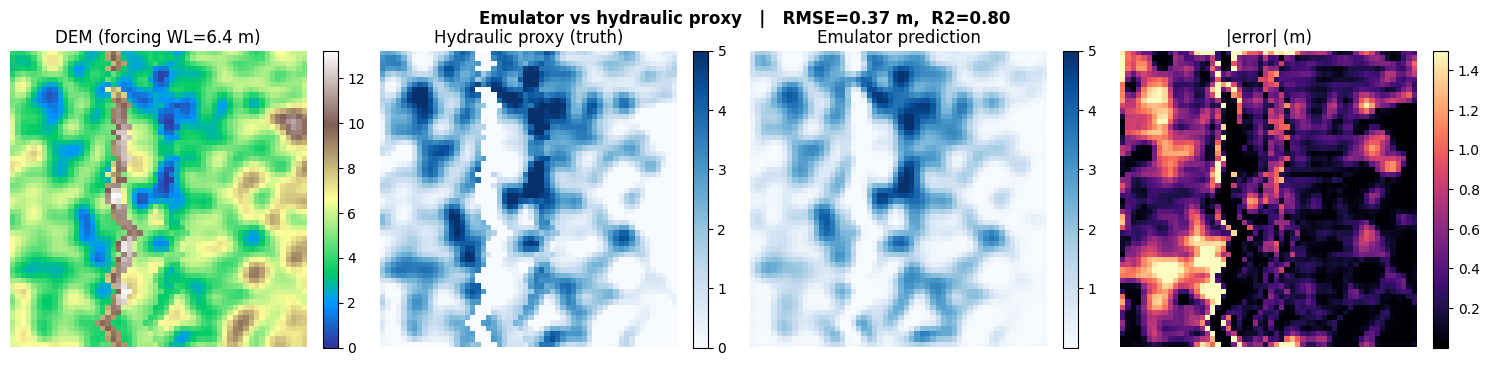

In [6]:
model.eval()
with torch.no_grad(): pred = model(Xv).numpy()
true = Yte
rmse = float(np.sqrt(((pred - true) ** 2).mean()))
r2 = float(1 - ((pred - true) ** 2).sum() / ((true - true.mean()) ** 2).sum())
print(f"TEST  RMSE = {rmse:.3f} m   R2 = {r2:.3f}")

k = int(np.argmax([(Yte[i] > 0).mean() for i in range(len(Yte))]))  # a well-flooded example
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
panels = [(Xte[k,0], f"DEM (forcing WL={WLte[k]:.1f} m)", "terrain", None),
          (true[k,0], "Hydraulic proxy (truth)", "Blues", 5),
          (pred[k,0], "Emulator prediction", "Blues", 5),
          (np.abs(pred[k,0]-true[k,0]), "|error| (m)", "magma", 1.5)]
for a,(img,t,cm,vx) in zip(ax, panels):
    im = a.imshow(img, cmap=cm, vmax=vx); a.axis("off"); a.set_title(t); fig.colorbar(im, ax=a, fraction=.046)
fig.suptitle(f"Emulator vs hydraulic proxy   |   RMSE={rmse:.2f} m,  R2={r2:.2f}", weight="bold")
plt.tight_layout(); plt.show()

## 2b \u00b7 Does it beat a naive baseline?

A demonstrator should show the emulator earns its complexity. Two references: a physically-naive
**bathtub** model that floods every cell below the water level (relu(water_level \u2212 elevation),
ignoring connectivity), and a **per-pixel linear regression** on (elevation, forcing). The U-Net
should beat both, because the real signal is the *connectivity* between the channel and each cell,
which neither baseline can represent.

Bathtub baseline   : RMSE=0.459 m   R2=0.693
Linear regression  : RMSE=0.634 m   R2=0.414
U-Net emulator     : RMSE=0.369 m   R2=0.801
-> emulator cuts RMSE by 20% vs bathtub and 42% vs linear


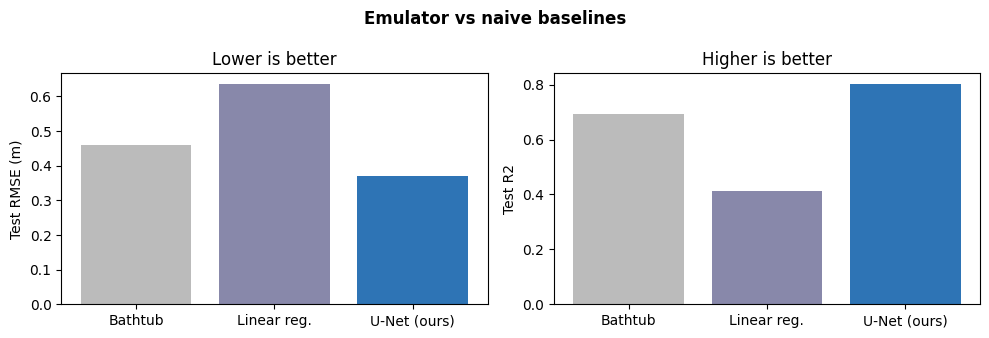

In [7]:
from sklearn.linear_model import LinearRegression

# 1) bathtub baseline: relu(water_level - elevation) -- floods every below-water cell
z_test = Xte[:, 0]; wl_test = WLte[:, None, None]
bathtub = np.clip(wl_test - z_test, 0, None)[:, None]
rmse_bt = float(np.sqrt(((bathtub - true) ** 2).mean()))
r2_bt = float(1 - ((bathtub - true) ** 2).sum() / ((true - true.mean()) ** 2).sum())

# 2) per-pixel linear regression on [elevation, forcing]
def feats(X): return np.stack([X[:, 0].ravel(), X[:, 1].ravel()], 1)
lr = LinearRegression().fit(feats(Xtr), Ytr.ravel())
lin = np.clip(lr.predict(feats(Xte)), 0, None).reshape(true.shape)
rmse_lin = float(np.sqrt(((lin - true) ** 2).mean()))
r2_lin = float(1 - ((lin - true) ** 2).sum() / ((true - true.mean()) ** 2).sum())

print(f"Bathtub baseline   : RMSE={rmse_bt:.3f} m   R2={r2_bt:.3f}")
print(f"Linear regression  : RMSE={rmse_lin:.3f} m   R2={r2_lin:.3f}")
print(f"U-Net emulator     : RMSE={rmse:.3f} m   R2={r2:.3f}")
print(f"-> emulator cuts RMSE by {100*(1-rmse/rmse_bt):.0f}% vs bathtub and {100*(1-rmse/rmse_lin):.0f}% vs linear")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
names = ["Bathtub", "Linear reg.", "U-Net (ours)"]
ax[0].bar(names, [rmse_bt, rmse_lin, rmse], color=["#bbbbbb", "#8888aa", "#2E74B5"])
ax[0].set_ylabel("Test RMSE (m)"); ax[0].set_title("Lower is better")
ax[1].bar(names, [r2_bt, r2_lin, r2], color=["#bbbbbb", "#8888aa", "#2E74B5"])
ax[1].set_ylabel("Test R2"); ax[1].set_title("Higher is better"); ax[1].axhline(0, color="k", lw=.6)
fig.suptitle("Emulator vs naive baselines", weight="bold"); plt.tight_layout(); plt.show()

## 3 · Probabilistic output (uncertainty quantification)

For flood risk, a point prediction is not enough — insurers and stress tests need to know *how
confident* the model is. Keeping dropout **active at inference** and averaging over many stochastic
forward passes (**MC-dropout**) gives a predictive mean and standard deviation per cell. We then
check **calibration**: how often the true depth falls inside the nominal 95% band.

mean predictive std = 0.075 m
95% band coverage — all cells: 0.87   flooded cells: 0.72


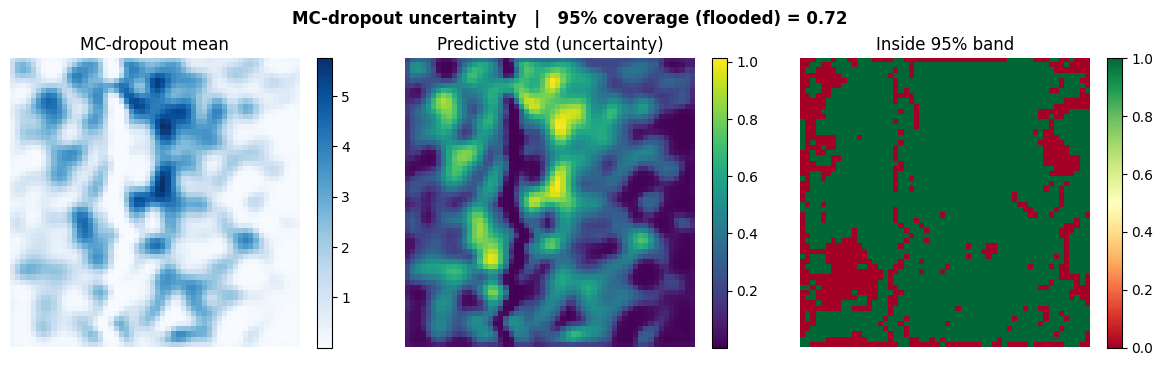

In [8]:
def mc_predict(x, T=30):
    model.train()                       # keep dropout ON
    with torch.no_grad():
        outs = torch.stack([model(x) for _ in range(T)])
    model.eval()
    return outs.mean(0).numpy(), outs.std(0).numpy()

mean_p, std_p = mc_predict(Xv, T=30)
lo, hi = mean_p - 1.96 * std_p, mean_p + 1.96 * std_p
cov_all = float(((true >= lo) & (true <= hi)).mean())
fmask = true > 0.05                     # coverage where it matters: actually-flooded cells
cov_flooded = float(((true >= lo) & (true <= hi))[fmask].mean())
print(f"mean predictive std = {std_p.mean():.3f} m")
print(f"95% band coverage — all cells: {cov_all:.2f}   flooded cells: {cov_flooded:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [(mean_p[k,0], "MC-dropout mean", "Blues"),
          (std_p[k,0], "Predictive std (uncertainty)", "viridis"),
          (((true>=lo)&(true<=hi))[k,0].astype(float), "Inside 95% band", "RdYlGn")]
for a,(img,t,cm) in zip(ax, panels):
    im = a.imshow(img, cmap=cm); a.axis("off"); a.set_title(t); fig.colorbar(im, ax=a, fraction=.046)
fig.suptitle(f"MC-dropout uncertainty   |   95% coverage (flooded) = {cov_flooded:.2f}", weight="bold")
plt.tight_layout(); plt.show()

Uncertainty concentrates along the **wet/dry transition zones** — exactly where a hydraulic
model's output is most sensitive — which is the qualitative behaviour we'd want. (A proper study
would compare MC-dropout against deep ensembles and quantile regression, and report reliability
diagrams, not a single coverage number.)

### 3b \u00b7 Is the uncertainty calibrated?

A single coverage number can hide miscalibration. The **reliability diagram** sweeps the nominal
central coverage from ~0 to ~1 and plots the observed fraction of flooded cells whose true depth
falls within that band. A well-calibrated model sits on the diagonal; the scalar **mean calibration
error (MCE)** summarises the gap.

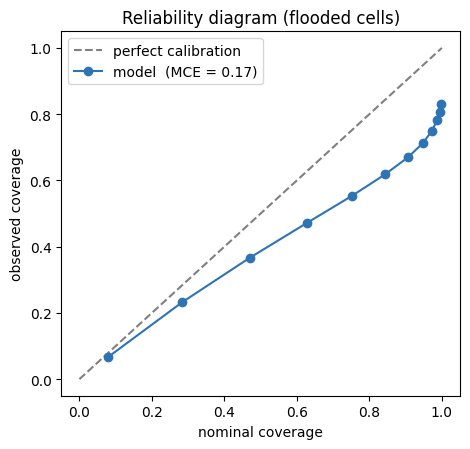

Mean calibration error (flooded cells): 0.167
Below the diagonal = over-confident (bands too narrow); above = under-confident.


In [9]:
import math
fm = true > 0.05                                   # evaluate where there is real signal
err = np.abs(true - mean_p)[fm]
sd = np.clip(std_p[fm], 1e-6, None)
z_grid = np.linspace(0.1, 3.0, 12)
nominal = np.array([math.erf(z / np.sqrt(2)) for z in z_grid])
observed = np.array([float((err <= z * sd).mean()) for z in z_grid])
mce = float(np.mean(np.abs(observed - nominal)))

plt.figure(figsize=(4.8, 4.6))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
plt.plot(nominal, observed, "o-", color="#2E74B5", label=f"model  (MCE = {mce:.2f})")
plt.xlabel("nominal coverage"); plt.ylabel("observed coverage")
plt.title("Reliability diagram (flooded cells)"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Mean calibration error (flooded cells): {mce:.3f}")
print("Below the diagonal = over-confident (bands too narrow); above = under-confident.")

## 4 · From emulation to an insurability map

Now the payoff. Take **one** catchment and, instead of running a hydraulic solver per return period,
use the **emulator** to produce depth maps across a set of return periods (higher return period →
higher forcing). Then:

1. **depth → damage** via a stylised saturating depth-damage curve (JRC-style), scaled by an asset-value grid;
2. **Expected Annual Damage (EAD)** = integral of damage over exceedance probability;
3. **insurability** = flag cells whose EAD exceeds an affordability threshold.

This is the chain the vacancy describes: fast scenarios → probabilistic impact → long-term
insurability maps.

EAD range [0.0000, 0.2546]   hard-to-insure cells: 15.0%


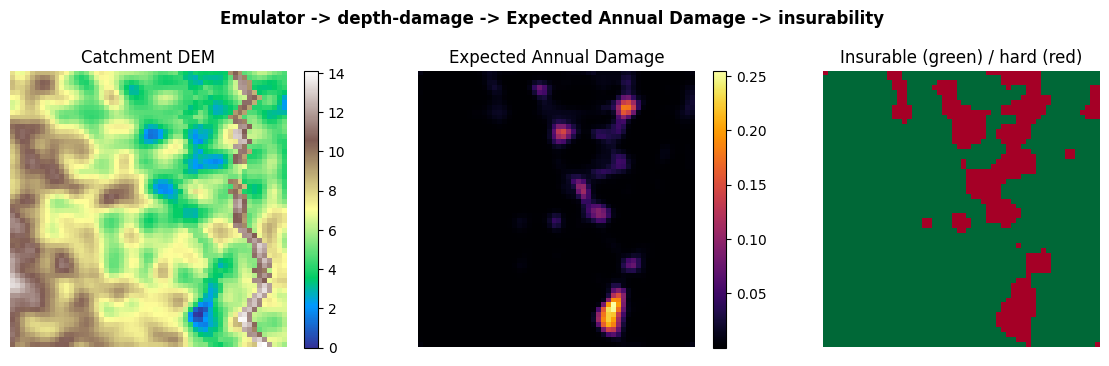

In [10]:
def depth_to_damage(depth):
    """Stylised saturating depth-damage curve: fraction of asset value lost."""
    return 1.0 - np.exp(-0.9 * depth)

z0, ch0 = make_terrain(np.random.default_rng(7))
asset = np.clip(1.0 + gaussian_random_field(N, 8.0, np.random.default_rng(8)), 0.2, None)

return_periods = np.array([10, 50, 100, 250, 500, 1000])
exceed_p = 1.0 / return_periods
levels = np.interp(np.log(return_periods), np.log([10, 1000]), [3.0, 6.5])  # RP -> forcing

def emulate(z, wl, T=30):
    x = ((np.stack([z, np.ones_like(z) * wl])[None] - xm) / xs).astype(np.float32)
    m, s = mc_predict(torch.tensor(x), T=T)
    return m[0, 0], s[0, 0]

depths = np.array([emulate(z0, wl)[0] for wl in levels])
damages = depth_to_damage(depths) * asset[None]
order = np.argsort(exceed_p)
EAD = np.trapezoid(damages[order], exceed_p[order], axis=0)   # per-cell expected annual damage
threshold = np.quantile(EAD, 0.85)
insurable = EAD <= threshold
print(f"EAD range [{EAD.min():.4f}, {EAD.max():.4f}]   hard-to-insure cells: {(~insurable).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
im = ax[0].imshow(z0, cmap="terrain"); ax[0].set_title("Catchment DEM"); ax[0].axis("off"); fig.colorbar(im, ax=ax[0], fraction=.046)
im = ax[1].imshow(EAD, cmap="inferno"); ax[1].set_title("Expected Annual Damage"); ax[1].axis("off"); fig.colorbar(im, ax=ax[1], fraction=.046)
im = ax[2].imshow(insurable, cmap="RdYlGn", vmin=0, vmax=1); ax[2].set_title("Insurable (green) / hard (red)"); ax[2].axis("off")
fig.suptitle("Emulator -> depth-damage -> Expected Annual Damage -> insurability", weight="bold")
plt.tight_layout(); plt.show()

## 5 · Honest limitations & how this scales to the real project

**What this is not.** The hydraulic "truth" is a flood-fill proxy, not a real solver; the depth-damage
curve, asset grid, and return-period→forcing mapping are stylised; and a single test catchment is not
a validation study. None of the numbers here are meaningful outside the toy setup — the value is the
*methodology and the end-to-end wiring*.

**How each toy piece maps to a real input**

| Toy component | Real counterpart in the FIRM project |
|---|---|
| Synthetic DEM | Copernicus DEM / AHN (Netherlands) elevation |
| Flood-fill proxy | Existing hydraulic scenario sets (the decades of modelling the project extends) |
| Random forcing | Sea/river levels & discharges with associated exceedance probabilities |
| Fixed depth-damage curve | JRC / sector depth-damage functions; real insurance claims data |
| Return-period sweep | KNMI'23 + IPCC climate scenarios for specific horizon years |

**Where I'd take the research next** (aligned with Pillar 3):
- Replace MC-dropout with **deep ensembles / quantile regression** and report proper calibration (reliability diagrams, CRPS).
- Move from emulation to **generating credible extreme scenarios beyond the historical range** (conditional generative models), which is the genuinely novel ask.
- Model **breach growth and regional-defence-failure uncertainty** explicitly, since these dominate tail risk.
- Validate on **data-rich (NL)** and **data-scarce** regions, and integrate outputs with the risk models of Pillars 1–2.

*Reproducibility:* fixed seeds throughout; runs top-to-bottom on CPU. Swap the data-generation
functions in §1 for real rasters and the rest of the pipeline is unchanged.